In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date']).dt.strftime('%b')
file['job_skills']=file['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

print(file.info())

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [56]:
data={
    'job_skills':['Python','SQL','Java','Power BI','C++'],
    'skill_count':[30,25,29,19,35],
    'Skill_Pay':[100,120,110,98,99]
}

df=pd.DataFrame(data)
type(df)

pandas.DataFrame

c:\Users\Maaz\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


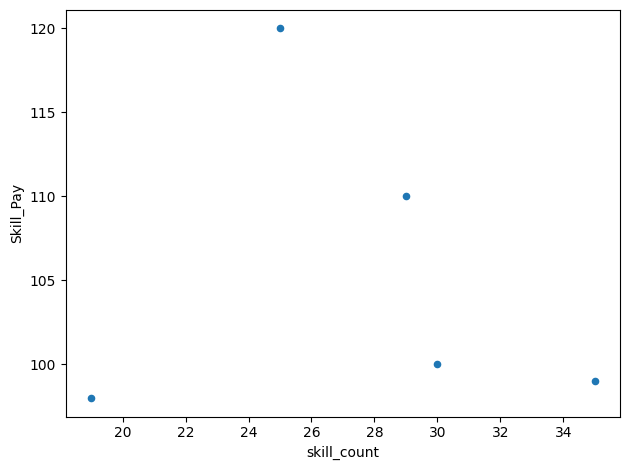

In [57]:
df.plot(kind='scatter',x='skill_count',y='Skill_Pay',colormap='viridis')
plt.tight_layout()
plt.show()

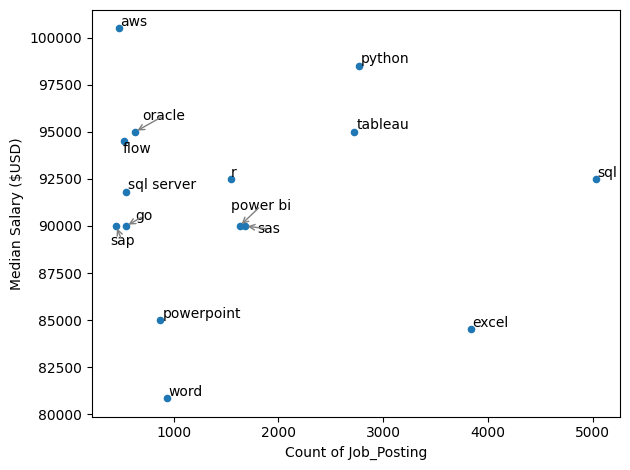

In [66]:
from adjustText import adjust_text


file_copy=file.copy()
file_copy=file_copy[file_copy['job_title_short']=='Data Analyst']
file_copy=file_copy.explode('job_skills')
skill_stats=file_copy.groupby('job_skills').agg(skill_count=('job_title_short','count'),median_salary=('salary_year_avg','median'))
skill_stats=skill_stats.sort_values(by='skill_count',ascending=False).head(15)

skill_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.xlabel('Count of Job_Posting')
plt.ylabel('Median Salary ($USD)')
plt.tight_layout()
texts=[]
for i,txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i],
                          skill_stats['median_salary'].iloc[i],txt))
adjust_text(texts,force_text=(0.5, 1),expand_text=(2.0, 3.0),arrowprops=dict(arrowstyle='->',color='gray'))

plt.tight_layout()